# Análisis Espacial de Hogares en CABA - Censo 2022

En este notebook vamos a realizar un análisis espacial de los datos censales de hogares en la Ciudad Autónoma de Buenos Aires (CABA) del año 2022.

## Objetivos
- Explorar la distribución espacial de hogares propietarios e inquilinos
- Identificar patrones de concentración espacial (hot spots y cold spots)
- Aplicar técnicas de autocorrelación espacial local (Gi*)

## 1. Importación de librerías y carga de datos

Comenzamos importando las librerías necesarias para el análisis espacial y la visualización de datos.

In [43]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import numpy as np
from libpysal.weights import Queen, DistanceBand
from esda.getisord import G_Local
import statsmodels.api as sm

%matplotlib inline
plt.rcParams["figure.figsize"] = (16, 12)

# Carga de datos
hogar_caba = gpd.read_file('data/Indicadores de hogares. Radios, 2022 - Ciudad Autónoma de Buenos Aires (CABA)/Indicadores de hogares. Radios, 2022 - Ciudad Autónoma de Buenos Aires (CABA).shp')
personas_caba = gpd.read_file('data/Indicadores de personas. Radios, 2022 - Ciudad Autónoma de Buenos Aires (CABA)/Indicadores de personas. Radios, 2022 - Ciudad Autónoma de Buenos Aires (CABA).shp')
barrios_caba = gpd.read_file('data/barrios.shp')

## 2. Exploración de las columnas disponibles

Antes de comenzar el análisis, exploramos las columnas disponibles en el dataset de hogares para identificar las variables de interés.

In [23]:
#print(personas_caba.columns)
print(hogar_caba.columns)   

Index(['REDCODE', 'H_TOTAL', 'H_NBI', 'H_COMPUTAD', 'H_DOMESTIC', 'H_HACINAMI',
       'H_HACINA_1', 'H_CADENA', 'H_AGUA_RED', 'H_AGUA_VIV', 'H_CLOACA',
       'H_HOYO', 'H_TECHO', 'H_CIELORRA', 'H_PISO', 'H_CELULAR', 'H_COMBUSTI',
       'H_PROPIETA', 'H_INQUILIN', 'H_NI_PROPI', 'H_JEFE_MUJ', 'H_JEFE_LIM',
       'H_JEFE_SOL', 'H_JEFE_S_1', 'H_JEFE_SEC', 'H_JEFE_TER', 'H_JEFE_UNI',
       'H_CONYUGE_', 'H_ESTRUCTU', 'H_ESTRUC_1', 'H_ESTRUC_2', 'H_ESTRUC_3',
       'H_ESTRUC_4', 'H_ESTRUC_5', 'H_ESTRUC_6', 'H_TAMANIO_', 'H_TAMANI_1',
       'H_TAMANI_2', 'H_TAMANI_3', 'H_TAMANI_4', 'CODPROV', 'PROV', 'CODDPTO',
       'DPTO', 'REDCODE_1', 'RADIO', 'RADIOS_POB', 'RADIOS_HOG', 'RADIOS_LAT',
       'RADIOS_LON', 'RADIOS_SUP', 'geometry'],
      dtype='object')


## 3. Visualización del total de hogares

Creamos un primer mapa coroplético para visualizar la distribución del total de hogares por radio censal en CABA.

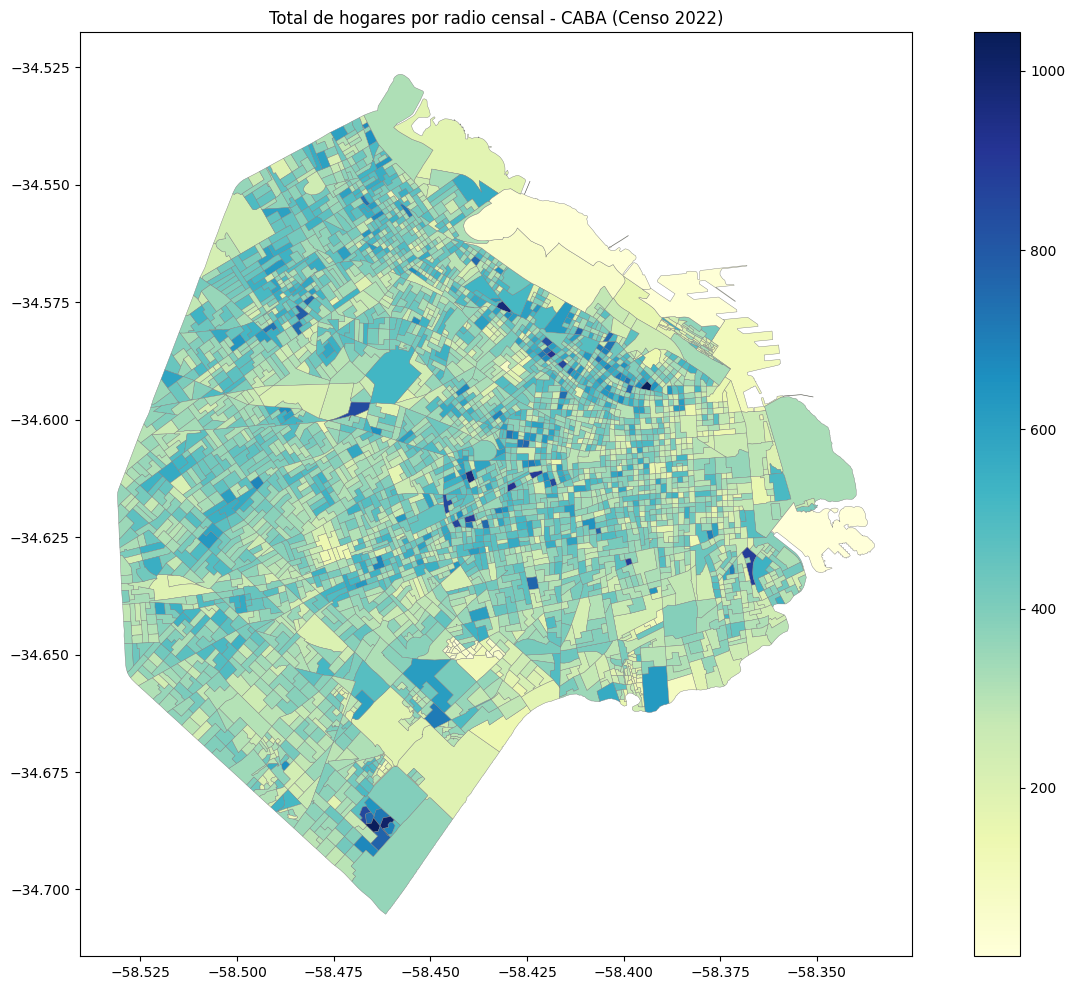

In [24]:
hogar_caba.plot(
    column="H_TOTAL",
    cmap="YlGnBu",
    linewidth=0.3,
    edgecolor="gray",
    legend=True
)

plt.title("Total de hogares por radio censal - CABA (Censo 2022)")
plt.show()

## 4. Comparación: Hogares propietarios vs inquilinos (valores absolutos)

Visualizamos lado a lado la distribución de hogares propietarios e inquilinos en valores absolutos para identificar patrones espaciales iniciales.

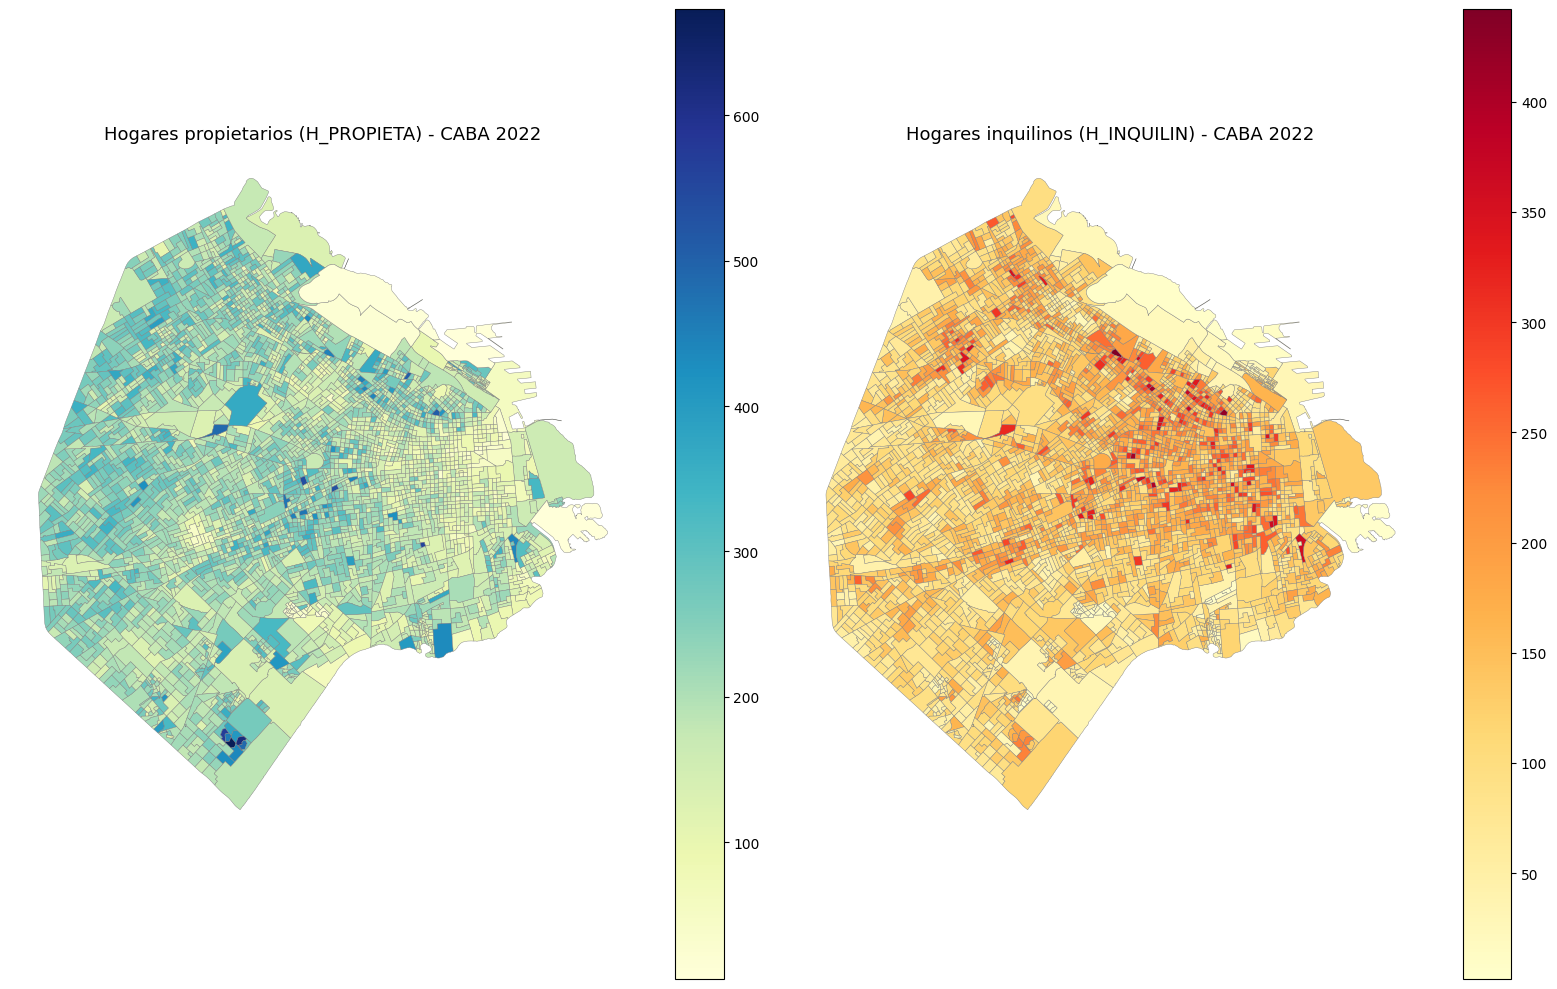

In [25]:
# Configurar la figura
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# --- Mapa 1: Hogares propietarios ---
hogar_caba.plot(
    column="H_PROPIETA",
    cmap="YlGnBu",
    linewidth=0.3,
    edgecolor="gray",
    legend=True,
    ax=axes[0]
)
axes[0].set_title("Hogares propietarios (H_PROPIETA) - CABA 2022", fontsize=13)
axes[0].axis("off")

# --- Mapa 2: Hogares inquilinos ---
hogar_caba.plot(
    column="H_INQUILIN",
    cmap="YlOrRd",
    linewidth=0.3,
    edgecolor="gray",
    legend=True,
    ax=axes[1]
)
axes[1].set_title("Hogares inquilinos (H_INQUILIN) - CABA 2022", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 5. Cálculo de proporciones

Para realizar un análisis más robusto, calculamos las proporciones de hogares inquilinos y propietarios respecto al total de hogares en cada radio censal. Esto nos permite comparar áreas con diferentes tamaños poblacionales.

In [5]:
# para trabajar con proporciones

hogar_caba["pct_inquilinos"] = hogar_caba["H_INQUILIN"] / hogar_caba["H_TOTAL"]
hogar_caba["pct_propietarios"] = hogar_caba["H_PROPIETA"] / hogar_caba["H_TOTAL"]

## 6. Visualización de proporciones

Comparamos las proporciones de hogares propietarios e inquilinos. Este mapa nos da una mejor perspectiva de la distribución relativa, independientemente del tamaño de cada radio censal.

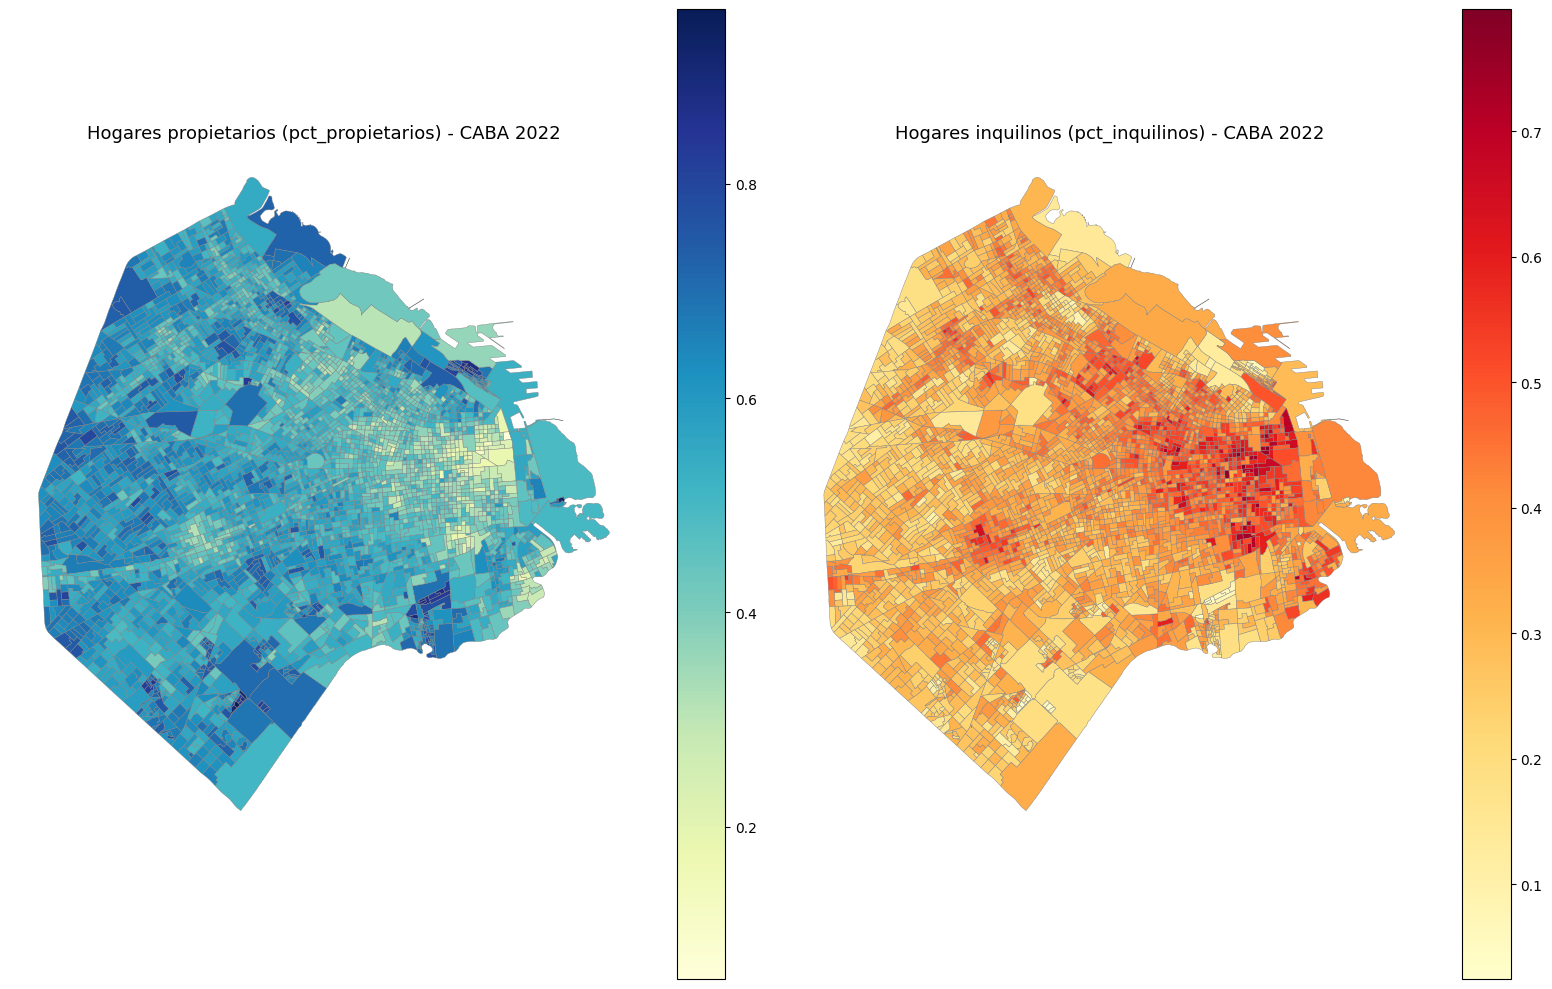

In [6]:
# Configurar la figura
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# --- Mapa 1: Hogares propietarios ---
hogar_caba.plot(
    column="pct_propietarios",
    cmap="YlGnBu",
    linewidth=0.3,
    edgecolor="gray",
    legend=True,
    ax=axes[0]
)
axes[0].set_title("Hogares propietarios (pct_propietarios) - CABA 2022", fontsize=13)
axes[0].axis("off")

# --- Mapa 2: Hogares inquilinos ---
hogar_caba.plot(
    column="pct_inquilinos",
    cmap="YlOrRd",
    linewidth=0.3,
    edgecolor="gray",
    legend=True,
    ax=axes[1]
)
axes[1].set_title("Hogares inquilinos (pct_inquilinos) - CABA 2022", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 7. Análisis de autocorrelación espacial local - Getis-Ord Gi*

### ¿Qué es Gi*?
El estadístico Getis-Ord Gi* nos permite identificar **hot spots** (concentraciones de valores altos) y **cold spots** (concentraciones de valores bajos) que son estadísticamente significativos.

### Preparación de la matriz de pesos espaciales
Primero, creamos una matriz de pesos espaciales usando el criterio de contigüidad Queen (vecinos que comparten borde o vértice).

### 7.1 Vecindarios por contiguidad Queen

In [7]:
# Preparamos los datos y la matriz de pesos espaciales
g = hogar_caba.copy()
g = g[g["H_TOTAL"] > 0]  # evitar divisiones por cero

# Crear matriz de pesos espaciales usando criterio Queen
w = Queen.from_dataframe(g)

C:\Users\tomas\AppData\Local\Temp\ipykernel_17760\204234845.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(g)


### 7.1.1 Análisis con estandarización binaria (B)

La estandarización binaria (B) es la forma clásica para Gi*. Testea si la **suma local** de valores es significativamente diferente de la suma global.

**Interpretación:**
- **Hot spots (rojo)**: Áreas donde tanto el radio como sus vecinos tienen valores altos
- **Cold spots (azul)**: Áreas donde tanto el radio como sus vecinos tienen valores bajos
- **No significativo (gris)**: Áreas sin patrón espacial significativo (p ≥ 0.05)

Islas (sin vecinos): 0


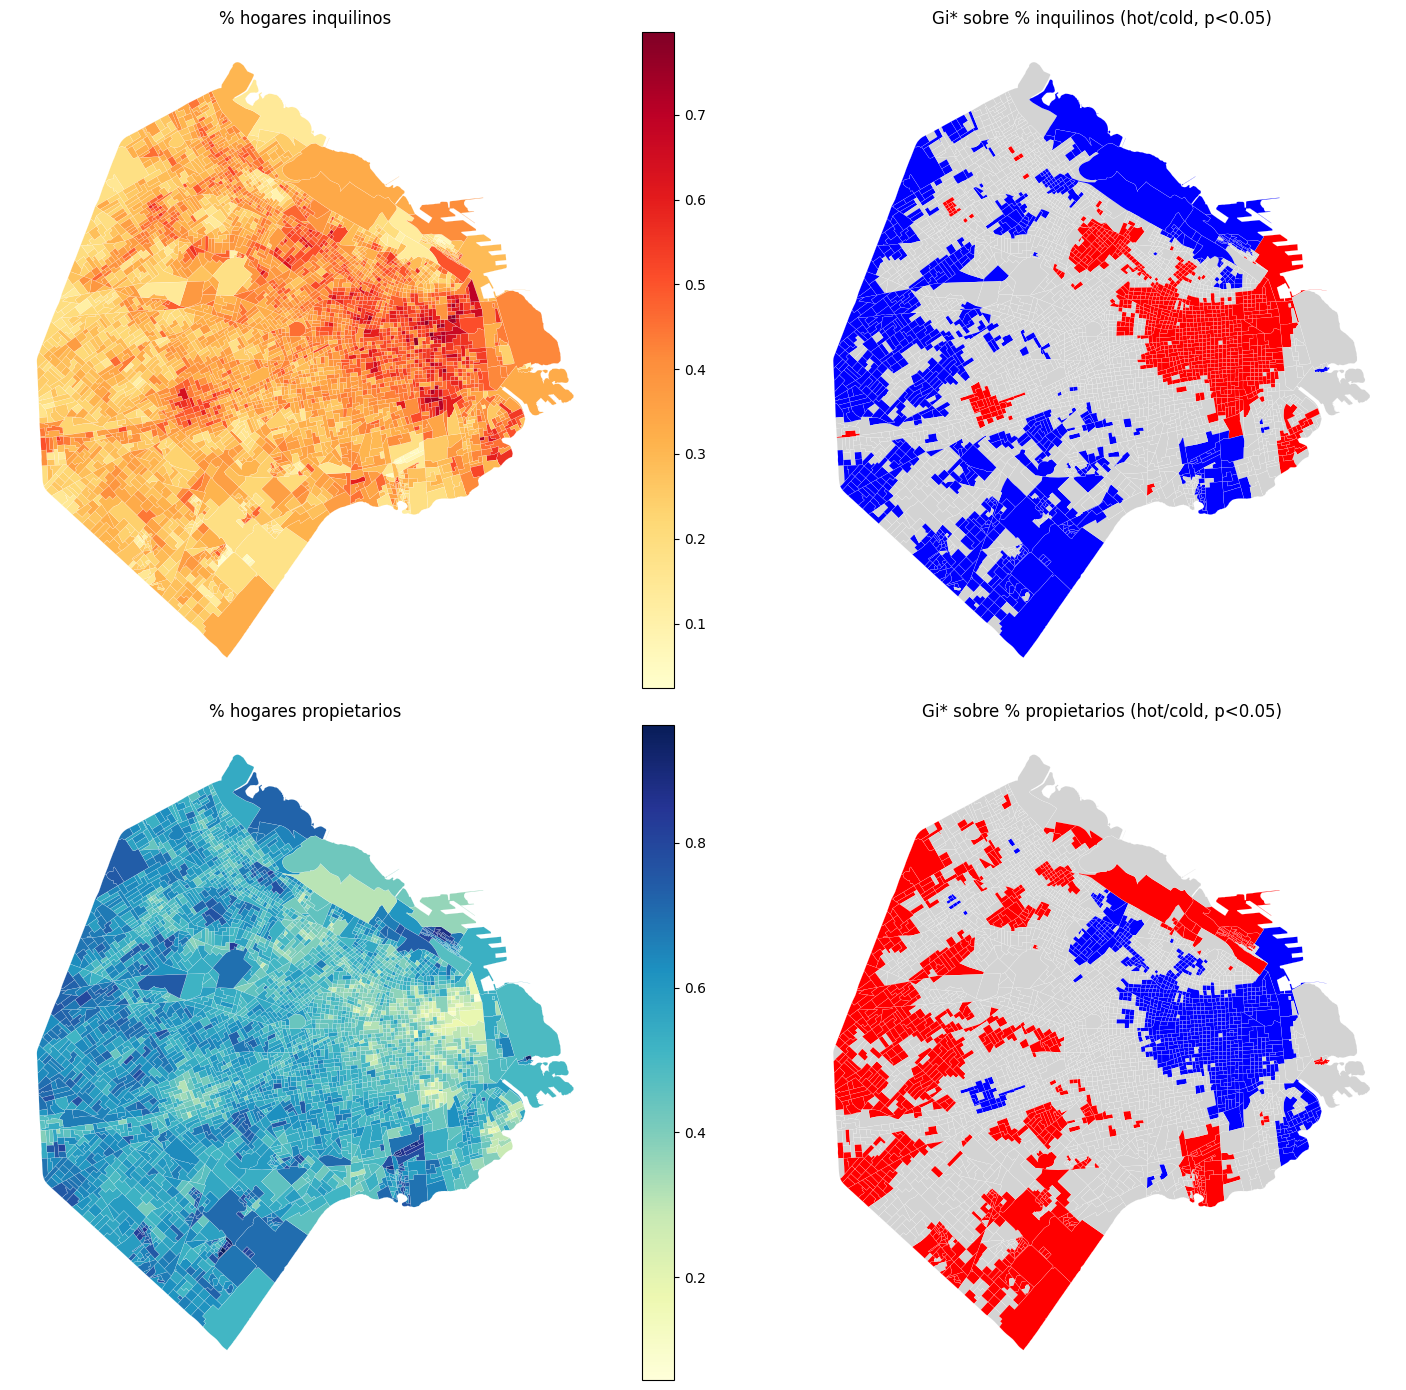

In [8]:
# Opciones de estandarización de pesos:
# - 'B' = binarios (clásico para Gi*; testea "suma" local frente a global)
# - 'R' = row-standardized (promedio local; menos sensible al # de vecinos)
w.transform = "B"   # <-- Cambiá a "R" si querés comparar

print(f"Islas (sin vecinos): {len(w.islands)}")
# Si hubiera islas y preferís forzar al menos 1 vecino, te paso un fix luego.

# 3) Gi* para % de hogares inquilinos
gi_inq = G_Local(g["pct_inquilinos"].values, w, star=True, permutations=999)
g["GiZ_inq"] = gi_inq.Zs          # z-score local (positivo=hot, negativo=cold)
g["p_inq"]   = gi_inq.p_sim       # p-valor por permutaciones

g["clase_inq"] = "ns"
g.loc[(g["p_inq"] < 0.05) & (g["GiZ_inq"] > 0), "clase_inq"] = "hot"
g.loc[(g["p_inq"] < 0.05) & (g["GiZ_inq"] < 0), "clase_inq"] = "cold"

# 4) Gi* para % de hogares propietarios
gi_prop = G_Local(g["pct_propietarios"].values, w, star=True, permutations=999)
g["GiZ_prop"] = gi_prop.Zs
g["p_prop"]   = gi_prop.p_sim

g["clase_prop"] = "ns"
g.loc[(g["p_prop"] < 0.05) & (g["GiZ_prop"] > 0), "clase_prop"] = "hot"
g.loc[(g["p_prop"] < 0.05) & (g["GiZ_prop"] < 0), "clase_prop"] = "cold"

# 5) Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# % inquilinos (coroplético)
g.plot(column="pct_inquilinos", cmap="YlOrRd", legend=True,
       edgecolor="white", linewidth=0.1, ax=axes[0,0])
axes[0,0].set_title("% hogares inquilinos")
axes[0,0].axis("off")

# Gi* inquilinos (hot/cold)
colors = {"hot":"red", "cold":"blue", "ns":"lightgrey"}
g.assign(_color=g["clase_inq"].map(colors)).plot(color=g["clase_inq"].map(colors),
       edgecolor="white", linewidth=0.1, ax=axes[0,1])
axes[0,1].set_title("Gi* sobre % inquilinos (hot/cold, p<0.05)")
axes[0,1].axis("off")

# % propietarios (coroplético)
g.plot(column="pct_propietarios", cmap="YlGnBu", legend=True,
       edgecolor="white", linewidth=0.1, ax=axes[1,0])
axes[1,0].set_title("% hogares propietarios")
axes[1,0].axis("off")

# Gi* propietarios (hot/cold)
g.assign(_color=g["clase_prop"].map(colors)).plot(color=g["clase_prop"].map(colors),
       edgecolor="white", linewidth=0.1, ax=axes[1,1])
axes[1,1].set_title("Gi* sobre % propietarios (hot/cold, p<0.05)")
axes[1,1].axis("off")

plt.tight_layout()
plt.show()

### 7.1.2 Análisis con estandarización por filas (R)

La estandarización por filas (R) calcula el **promedio local** en lugar de la suma. Es menos sensible al número de vecinos que tiene cada radio censal.

**Diferencias con la estandarización B:**
- Más apropiada cuando los radios tienen diferente número de vecinos
- Enfatiza el promedio de la vecindad en lugar de la suma total
- Puede revelar patrones diferentes, especialmente en áreas con geometrías irregulares

Islas (sin vecinos): 0


C:\Users\tomas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
C:\Users\tomas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximu

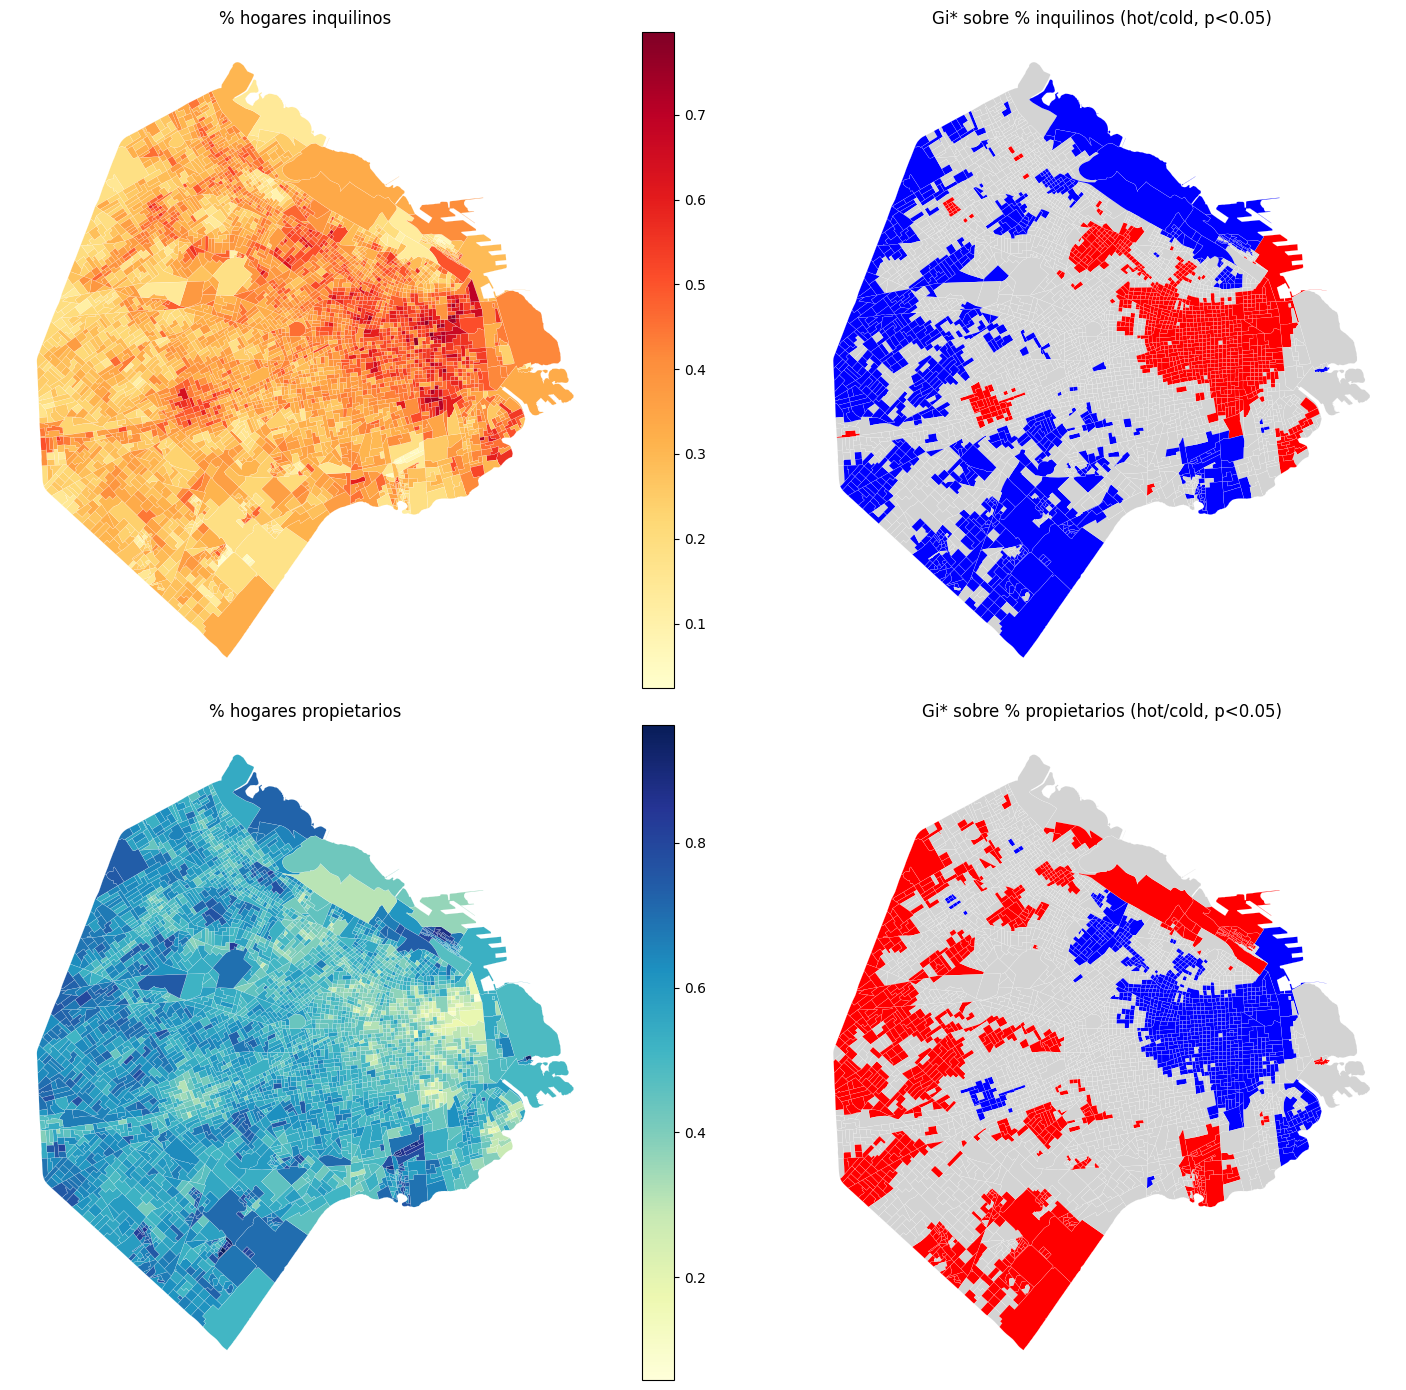

In [9]:
# Opciones de estandarización de pesos:
# - 'B' = binarios (clásico para Gi*; testea "suma" local frente a global)
# - 'R' = row-standardized (promedio local; menos sensible al # de vecinos)
w.transform = "R"   # <-- Cambiá a "R" si querés comparar

print(f"Islas (sin vecinos): {len(w.islands)}")
# Si hubiera islas y preferís forzar al menos 1 vecino, te paso un fix luego.

# 3) Gi* para % de hogares inquilinos
gi_inq = G_Local(g["pct_inquilinos"].values, w, star=True, permutations=999)
g["GiZ_inq"] = gi_inq.Zs          # z-score local (positivo=hot, negativo=cold)
g["p_inq"]   = gi_inq.p_sim       # p-valor por permutaciones

g["clase_inq"] = "ns"
g.loc[(g["p_inq"] < 0.05) & (g["GiZ_inq"] > 0), "clase_inq"] = "hot"
g.loc[(g["p_inq"] < 0.05) & (g["GiZ_inq"] < 0), "clase_inq"] = "cold"

# 4) Gi* para % de hogares propietarios
gi_prop = G_Local(g["pct_propietarios"].values, w, star=True, permutations=999)
g["GiZ_prop"] = gi_prop.Zs
g["p_prop"]   = gi_prop.p_sim

g["clase_prop"] = "ns"
g.loc[(g["p_prop"] < 0.05) & (g["GiZ_prop"] > 0), "clase_prop"] = "hot"
g.loc[(g["p_prop"] < 0.05) & (g["GiZ_prop"] < 0), "clase_prop"] = "cold"

# 5) Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# % inquilinos (coroplético)
g.plot(column="pct_inquilinos", cmap="YlOrRd", legend=True,
       edgecolor="white", linewidth=0.1, ax=axes[0,0])
axes[0,0].set_title("% hogares inquilinos")
axes[0,0].axis("off")

# Gi* inquilinos (hot/cold)
colors = {"hot":"red", "cold":"blue", "ns":"lightgrey"}
g.assign(_color=g["clase_inq"].map(colors)).plot(color=g["clase_inq"].map(colors),
       edgecolor="white", linewidth=0.1, ax=axes[0,1])
axes[0,1].set_title("Gi* sobre % inquilinos (hot/cold, p<0.05)")
axes[0,1].axis("off")

# % propietarios (coroplético)
g.plot(column="pct_propietarios", cmap="YlGnBu", legend=True,
       edgecolor="white", linewidth=0.1, ax=axes[1,0])
axes[1,0].set_title("% hogares propietarios")
axes[1,0].axis("off")

# Gi* propietarios (hot/cold)
g.assign(_color=g["clase_prop"].map(colors)).plot(color=g["clase_prop"].map(colors),
       edgecolor="white", linewidth=0.1, ax=axes[1,1])
axes[1,1].set_title("Gi* sobre % propietarios (hot/cold, p<0.05)")
axes[1,1].axis("off")

plt.tight_layout()
plt.show()

### 7.2 Vecindario por distancias

In [52]:
# Proyectar a un CRS métrico (Web Mercator está bien para exploración)
g = hogar_caba.copy()
g = g.to_crs(3857)  # EPSG:3857

g = g[g["H_TOTAL"] >= 30].reset_index(drop=True)

g["pct_inquilinos"] = g["H_INQUILIN"] / g["H_TOTAL"]
g["pct_propietarios"] = g["H_PROPIETA"] / g["H_TOTAL"]

# Filtrar radios con H_TOTAL muy chico para evitar proporciones locas
g = g.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["pct_inquilinos", "pct_propietarios"]
)

#### Construcción de pesos espaciales por bandas de distancia

En esta sección definimos los **vecindarios espaciales** en función de la distancia entre radios censales.  
La idea es seguir el enfoque de Getis–Ord (1992), donde el estadístico $G_i^*(d)$ depende explícitamente de un radio \(d\):  
solo se consideran vecinos aquellos radios ubicados a una distancia menor o igual a \(d\).

Trabajamos con varias **bandas de distancia** en metros:

```python
distance_bands = [400, 600, 800, 1000, 1200]

In [57]:
# Distancias en metros (ejemplo)
distance_bands = [400, 600, 800, 1000, 1200]

weights_by_d = {}
rows = []

for d in distance_bands:
    w = DistanceBand.from_dataframe(
        g, 
        threshold=d,
        silence_warnings=True,  # no spamee por islas
        binary=True,            # w_ij = 1 si dist<=d
        # use_kdtree=True       # opcional, acelera
    )
    weights_by_d[d] = w
    
    cards = np.array([len(nbrs) for nbrs in w.neighbors.values()])
    
    rows.append({
        "distancia_m": d,
        "n_islas": len(w.islands),
        "vecinos_min": int(cards.min()),
        "vecinos_mediana": float(np.median(cards)),
        "vecinos_max": int(cards.max())
    })

# DataFrame resumen
resumen_vecindarios = pd.DataFrame(rows)
resumen_vecindarios

,distancia_m,n_islas,vecinos_min,vecinos_mediana,vecinos_max
0,400,44,0,9.0,28
1,600,14,0,20.0,54
2,800,3,0,35.0,89
3,1000,0,1,53.0,132
4,1200,0,2,75.0,185


In [54]:
def run_gistar(series, weights, perms=999):
    gi = G_Local(series.values, weights, star=True, permutations=perms)
    return gi.Zs, gi.p_sim

# Diccionarios para guardar resultados por distancia y por variable
GiZ_inq_by_d   = {}
p_inq_by_d     = {}
class_inq_by_d = {}

GiZ_prop_by_d   = {}
p_prop_by_d     = {}
class_prop_by_d = {}

for d, w in weights_by_d.items():
    w.transform = "R"
    
    # --- Inquilinos ---
    Zs_inq, p_inq = run_gistar(g["pct_inquilinos"], w, perms=999)
    GiZ_inq_by_d[d] = Zs_inq
    p_inq_by_d[d]   = p_inq
    
    clase_inq = np.full(len(g), "ns", dtype=object)
    clase_inq[(p_inq < 0.05) & (Zs_inq > 0)] = "hot"
    clase_inq[(p_inq < 0.05) & (Zs_inq < 0)] = "cold"
    class_inq_by_d[d] = clase_inq

    # --- Propietarios ---
    Zs_prop, p_prop = run_gistar(g["pct_propietarios"], w, perms=999)
    GiZ_prop_by_d[d] = Zs_prop
    p_prop_by_d[d]   = p_prop
    
    clase_prop = np.full(len(g), "ns", dtype=object)
    clase_prop[(p_prop < 0.05) & (Zs_prop > 0)] = "hot"
    clase_prop[(p_prop < 0.05) & (Zs_prop < 0)] = "cold"
    class_prop_by_d[d] = clase_prop

# Guardar todo en el GeoDataFrame con nombres claros
for d in distance_bands:
    # Inquilinos
    g[f"GiZ_inq_{d}"]   = GiZ_inq_by_d[d]
    g[f"p_inq_{d}"]     = p_inq_by_d[d]
    g[f"clase_inq_{d}"] = class_inq_by_d[d]
    
    # Propietarios
    g[f"GiZ_prop_{d}"]   = GiZ_prop_by_d[d]
    g[f"p_prop_{d}"]     = p_prop_by_d[d]
    g[f"clase_prop_{d}"] = class_prop_by_d[d]

c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 52 disconnected components.
 There are 44 islands with ids: 0, 59, 61, 62, 672, 874, 876, 887, 915, 936, 1105, 1134, 1137, 1146, 1148, 1149, 1150, 1156, 1165, 1183, 1371, 1377, 1389, 1391, 1433, 1444, 1449, 1945, 1946, 1947, 2244, 2350, 2362, 2367, 2698, 2704, 2

('WARNING: ', 0, ' is an island (no neighbors)')
('WARNING: ', 59, ' is an island (no neighbors)')
('WARNING: ', 61, ' is an island (no neighbors)')
('WARNING: ', 62, ' is an island (no neighbors)')
('WARNING: ', 672, ' is an island (no neighbors)')
('WARNING: ', 874, ' is an island (no neighbors)')
('WARNING: ', 876, ' is an island (no neighbors)')
('WARNING: ', 887, ' is an island (no neighbors)')
('WARNING: ', 915, ' is an island (no neighbors)')
('WARNING: ', 936, ' is an island (no neighbors)')
('WARNING: ', 1105, ' is an island (no neighbors)')
('WARNING: ', 1134, ' is an island (no neighbors)')
('WARNING: ', 1137, ' is an island (no neighbors)')
('WARNING: ', 1146, ' is an island (no neighbors)')
('WARNING: ', 1148, ' is an island (no neighbors)')
('WARNING: ', 1149, ' is an island (no neighbors)')
('WARNING: ', 1150, ' is an island (no neighbors)')
('WARNING: ', 1156, ' is an island (no neighbors)')
('WARNING: ', 1165, ' is an island (no neighbors)')
('WARNING: ', 1183, ' is an

c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:450: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Gs - self.EG_sim) / self.seG_sim
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 52 disconnected components.
 There are 44 islands with ids:

('WARNING: ', 0, ' is an island (no neighbors)')
('WARNING: ', 59, ' is an island (no neighbors)')
('WARNING: ', 61, ' is an island (no neighbors)')
('WARNING: ', 62, ' is an island (no neighbors)')
('WARNING: ', 672, ' is an island (no neighbors)')
('WARNING: ', 874, ' is an island (no neighbors)')
('WARNING: ', 876, ' is an island (no neighbors)')
('WARNING: ', 887, ' is an island (no neighbors)')
('WARNING: ', 915, ' is an island (no neighbors)')
('WARNING: ', 936, ' is an island (no neighbors)')
('WARNING: ', 1105, ' is an island (no neighbors)')
('WARNING: ', 1134, ' is an island (no neighbors)')
('WARNING: ', 1137, ' is an island (no neighbors)')
('WARNING: ', 1146, ' is an island (no neighbors)')
('WARNING: ', 1148, ' is an island (no neighbors)')
('WARNING: ', 1149, ' is an island (no neighbors)')
('WARNING: ', 1150, ' is an island (no neighbors)')
('WARNING: ', 1156, ' is an island (no neighbors)')
('WARNING: ', 1165, ' is an island (no neighbors)')
('WARNING: ', 1183, ' is an

c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:527: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:450: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Gs - self.EG_sim) / self.seG_sim
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
c:\Users\USU

...

c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:450: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Gs - self.EG_sim) / self.seG_sim
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 3 islands with ids: 8

('WARNING: ', 874, ' is an island (no neighbors)')
('WARNING: ', 2244, ' is an island (no neighbors)')
('WARNING: ', 2350, ' is an island (no neighbors)')


c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:450: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Gs - self.EG_sim) / self.seG_sim
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There are 3 islands with ids: 8

('WARNING: ', 874, ' is an island (no neighbors)')
('WARNING: ', 2244, ' is an island (no neighbors)')
('WARNING: ', 2350, ' is an island (no neighbors)')


c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:527: RuntimeWarning: invalid value encountered in divide
  z_scores = (statistic - expected_value) / np.sqrt(expected_variance)
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:450: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Gs - self.EG_sim) / self.seG_sim
c:\Users\USUARIO\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)
c:\Users\USU

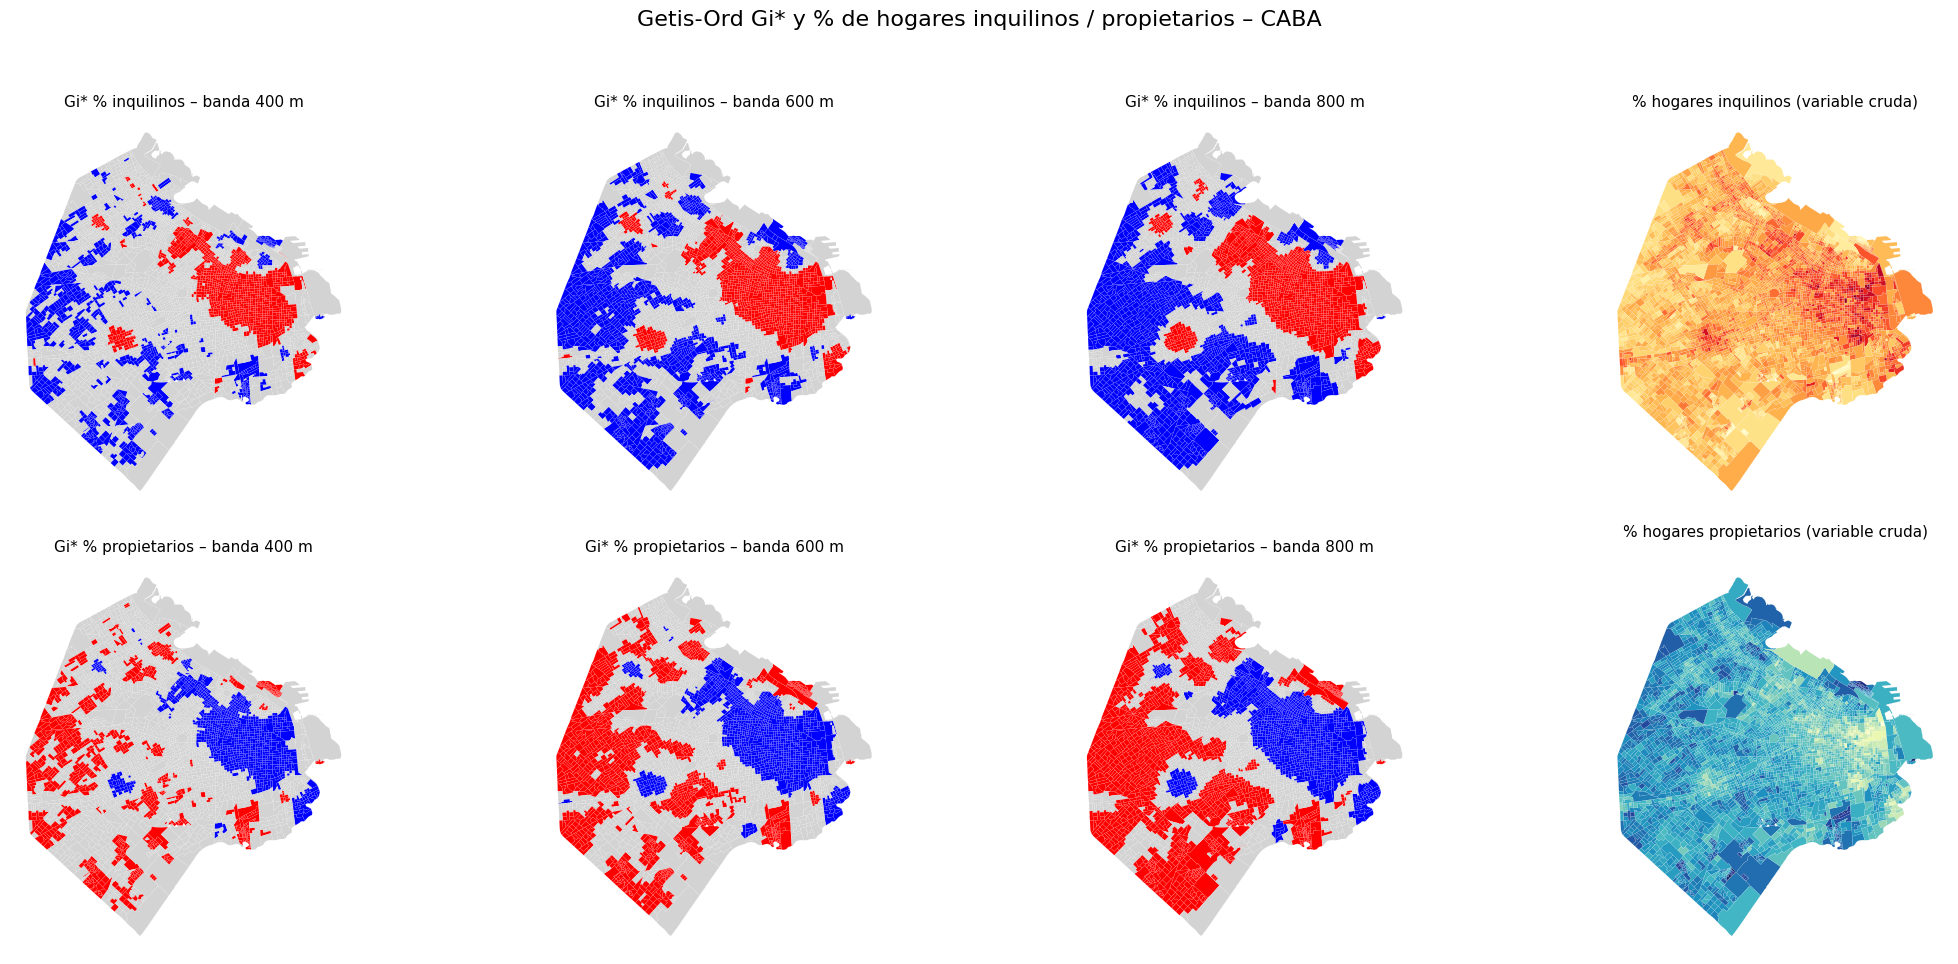

In [58]:
# Distancias a mostrar
distances_to_plot = [400, 600, 800]

# Colores para Gi*
colors = {"hot": "red", "cold": "blue", "ns": "lightgrey"}

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle("Getis-Ord Gi* y % de hogares inquilinos / propietarios – CABA", fontsize=16, y=0.96)

# ------------- #
# FILA 1: INQUILINOS
# ------------- #

# Mapas Gi* % inquilinos (3 distancias)
for ax, d in zip(axes[0, 0:3], distances_to_plot):
    g.plot(
        ax=ax,
        color=[colors[c] for c in g[f"clase_inq_{d}"]],
        edgecolor="white",
        linewidth=0.05
    )
    ax.set_title(f"Gi* % inquilinos – banda {d} m", fontsize=11)
    ax.axis("off")

# 4º mapa: variable cruda % inquilinos
vmin_inq = g["pct_inquilinos"].min()
vmax_inq = g["pct_inquilinos"].max()

ax = axes[0, 3]
g.plot(
    ax=ax,
    column="pct_inquilinos",
    cmap="YlOrRd",
    vmin=vmin_inq, vmax=vmax_inq,
    edgecolor="white",
    linewidth=0.05,
    legend=False  # sin barra como pediste
)
ax.set_title("% hogares inquilinos (variable cruda)", fontsize=11)
ax.axis("off")

# ------------- #
# FILA 2: PROPIETARIOS
# ------------- #

# Mapas Gi* % propietarios (3 distancias)
for ax, d in zip(axes[1, 0:3], distances_to_plot):
    g.plot(
        ax=ax,
        color=[colors[c] for c in g[f"clase_prop_{d}"]],
        edgecolor="white",
        linewidth=0.05
    )
    ax.set_title(f"Gi* % propietarios – banda {d} m", fontsize=11)
    ax.axis("off")

# 4º mapa: variable cruda % propietarios
vmin_prop = g["pct_propietarios"].min()
vmax_prop = g["pct_propietarios"].max()

ax = axes[1, 3]
g.plot(
    ax=ax,
    column="pct_propietarios",
    cmap="YlGnBu",
    vmin=vmin_prop, vmax=vmax_prop,
    edgecolor="white",
    linewidth=0.05,
    legend=False
)
ax.set_title("% hogares propietarios (variable cruda)", fontsize=11)
ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

### Estabilidad del patrón de hotspots/coldspots entre escalas

Para evaluar qué tan sensibles son los resultados del estadístico Gi* a la elección de la banda de distancia, comparamos los patrones de hotspots y coldspots obtenidos para \(d = 400\), \(600\) y \(800\) metros.  
En lugar de mirar solo mapas, cuantificamos la **superposición entre conjuntos** de radios significativos mediante el **índice de Jaccard**:

$$
J(A,B) = \frac{|A \cap B|}{|A \cup B|}
$$

donde \(A\) y \(B\) son, por ejemplo, los conjuntos de radios clasificados como *hotspots* a dos distancias distintas.  
Valores cercanos a 1 indican que los mismos radios aparecen como hotspot/coldspot en ambas escalas (patrón estable); valores bajos indican que el patrón cambia fuertemente al modificar la distancia.  

A continuación se construyen las matrices de Jaccard para hotspots y coldspots de **% de hogares inquilinos**, y para **% de hogares propietarios**,  

comparando todas las combinaciones de bandas de distancia consideradas.

In [56]:
# Distancias que querés comparar
distances = [400, 600, 800]

def jaccard(mask1, mask2):
    inter = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    return inter / union if union > 0 else np.nan

# Matrices Jaccard
jacc_inq_hot  = pd.DataFrame(index=distances, columns=distances, dtype=float)
jacc_inq_cold = pd.DataFrame(index=distances, columns=distances, dtype=float)

jacc_prop_hot  = pd.DataFrame(index=distances, columns=distances, dtype=float)
jacc_prop_cold = pd.DataFrame(index=distances, columns=distances, dtype=float)

for d1 in distances:
    for d2 in distances:
        # Inquilinos
        hot1_inq  = (g[f"clase_inq_{d1}"]  == "hot")
        hot2_inq  = (g[f"clase_inq_{d2}"]  == "hot")
        cold1_inq = (g[f"clase_inq_{d1}"]  == "cold")
        cold2_inq = (g[f"clase_inq_{d2}"]  == "cold")
        
        jacc_inq_hot.loc[d1, d2]  = jaccard(hot1_inq,  hot2_inq)
        jacc_inq_cold.loc[d1, d2] = jaccard(cold1_inq, cold2_inq)

        # Propietarios
        hot1_prop  = (g[f"clase_prop_{d1}"] == "hot")
        hot2_prop  = (g[f"clase_prop_{d2}"] == "hot")
        cold1_prop = (g[f"clase_prop_{d1}"] == "cold")
        cold2_prop = (g[f"clase_prop_{d2}"] == "cold")
        
        jacc_prop_hot.loc[d1, d2]  = jaccard(hot1_prop,  hot2_prop)
        jacc_prop_cold.loc[d1, d2] = jaccard(cold1_prop, cold2_prop)

print("Jaccard hotspots – INQUILINOS")
display(jacc_inq_hot)

print("Jaccard coldspots – INQUILINOS")
display(jacc_inq_cold)

print("Jaccard hotspots – PROPIETARIOS")
display(jacc_prop_hot)

print("Jaccard coldspots – PROPIETARIOS")
display(jacc_prop_cold)

Jaccard hotspots – INQUILINOS


,400,600,800
400,1.000000,0.803955,0.728987
600,0.803955,1.000000,0.870588
800,0.728987,0.870588,1.000000


Jaccard coldspots – INQUILINOS


,400,600,800
400,1.000000,0.585237,0.488218
600,0.585237,1.000000,0.764577
800,0.488218,0.764577,1.000000


Jaccard hotspots – PROPIETARIOS


,400,600,800
400,1.000000,0.616226,0.503321
600,0.616226,1.000000,0.755343
800,0.503321,0.755343,1.000000


Jaccard coldspots – PROPIETARIOS


,400,600,800
400,1.000000,0.830435,0.768362
600,0.830435,1.000000,0.902008
800,0.768362,0.902008,1.000000


## 8. Análisis de valores absolutos con modelo Poisson

### ¿Por qué usar un modelo Poisson?

Cuando trabajamos con **conteos** (valores absolutos) en lugar de proporciones, debemos considerar que:
- Los radios censales tienen diferentes tamaños poblacionales
- Un radio con más hogares naturalmente tendrá más inquilinos y/o propietarios

### Solución: Modelo Poisson con offset

Usamos un modelo GLM Poisson con `offset = log(H_TOTAL)` para:
1. Calcular los valores **esperados** de inquilinos según el tamaño del radio
2. Obtener **residuales estandarizados** (diferencia entre observado y esperado)
3. Aplicar Gi* sobre estos residuales para identificar hot/cold spots

**Interpretación:**
- **Hot spots**: Áreas con más inquilinos de lo esperado dado su tamaño
- **Cold spots**: Áreas con menos inquilinos de lo esperado dado su tamaño

### 8.1. Visualización de hot/cold spots sobre residuales

Este mapa muestra las áreas donde hay un exceso (hot) o déficit (cold) de hogares inquilinos respecto a lo esperado, controlando por el tamaño poblacional de cada radio censal.

### Hot y Cold spots de Valores absolutos

In [10]:
g = hogar_caba.copy()
g = g[g["H_TOTAL"] > 0]  # evitar divisiones por cero

# Poisson con offset = log(H_TOTAL): expectativa proporcional al tamaño
y = g["H_INQUILIN"].astype(float)
X = sm.add_constant(np.ones(len(g)))   # solo intercepto (tasa global)
m = sm.GLM(y, X, family=sm.families.Poisson(), offset=np.log(g["H_TOTAL"]))
fit = m.fit()

g["mu_exp"]     = fit.mu                         # esperados
g["resid_pear"] = (y - g["mu_exp"]) / np.sqrt(g["mu_exp"])  # residuales estandarizados

# Gi* sobre residuales (exceso/defecto local)
w = Queen.from_dataframe(g); w.transform = "R"   # o "B"; con conteos suele convenir "R"
gi = G_Local(g["resid_pear"].values, w, star=True, permutations=999)
g["GiZ_res"] = gi.Zs
g["p_res"]   = gi.p_sim

C:\Users\tomas\AppData\Local\Temp\ipykernel_17760\1851957046.py:14: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(g); w.transform = "R"   # o "B"; con conteos suele convenir "R"
C:\Users\tomas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\esda\getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)


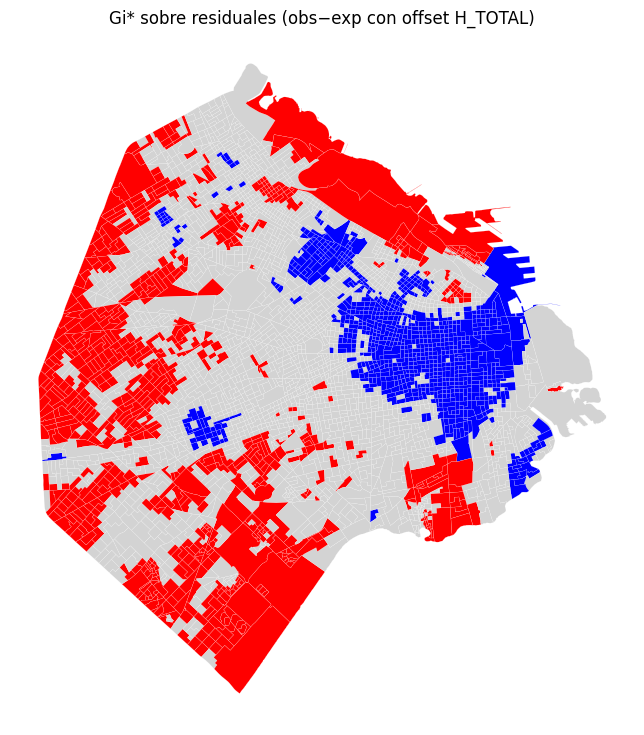

In [11]:

g["cls"] = "ns"
g.loc[(g["p_res"]<0.05) & (g["GiZ_res"]>0), "cls"] = "hot"
g.loc[(g["p_res"]<0.05) & (g["GiZ_res"]<0), "cls"] = "cold"

fig, ax = plt.subplots(figsize=(9,9))
colors = {"hot":"red","cold":"blue","ns":"lightgrey"}
g.plot(color=g["cls"].map(colors), edgecolor="white", linewidth=0.1, ax=ax)
ax.set_title("Gi* sobre residuales (obs−exp con offset H_TOTAL)")
ax.axis("off")
plt.show()